In [ ]:
import os

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

from datatree import open_datatree
from var_assim.plotting.presets import get_presets
from scipy.stats import describe

In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

In [3]:
# simulation config
cwd = os.getcwd()
prefix = 'margobs_ws'
ssp = 'ssp245'
model = 'pco2geowc3'
TMIN = 2025
AR = '1'
angles_file = ['9', '12', '14', '17', '21', '33']
ECS = 3.0
DEGpDEC = '0.1'
NYRSRAMP = 50
Nwinds = '14custom'
Nens = 500

# import files and convert to datatrees
fnames = [
    cwd + '/../../model/data/output/' + model + '/'
    + prefix + '_' + ssp + '_' + model + '_TMIN' + str(TMIN) + '_AR' + AR + '_THETA' + th + '_ECS' + str(ECS)
    + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nwinds' + Nwinds + '_Nens' + str(Nens) + '.nc'
    for th in angles_file
]
    
dts = [open_datatree(f, engine='netcdf4') for f in fnames]

In [4]:
# important simulation constants
L_CEN = 4.58 * np.log(2) / ECS  # central value of feedback parameter
G_CEN = 0.7
EPS_CEN = 1.58
F_EFF_GEO = 0.09  # efficacy
ALPHA_R1_CEN = 2.0  # central value of alpha r1 dist
ALPHA_R2_CEN = 1.3  # central value of alpha r2 dist

In [5]:
dat = dts[0]
dat

DataTree('None', parent=None)
├── DataTree('2027')
│       Dimensions:         (ens_mem: 500, vari: 21, time: 3, iter: 101, obs_var: 5)
│       Coordinates:
│         * time            (time) float64 2.025e+03 2.026e+03 2.027e+03
│         * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
│         * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q0' 'q1' 'q2'
│         * ens_mem         (ens_mem) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│         * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2' 'T_R3'
│       Data variables:
│           data_final      (ens_mem, vari, time) float64 ...
│           l2s             (ens_mem) float64 ...
│           costs           (ens_mem) float64 ...
│           controls        (ens_mem, vari) float64 ...
│           data_hist       (ens_mem, vari, iter, time) float64 ...
│           l2_hist         (ens_mem, iter) float64 ...
│           cost_hist       (ens_mem, iter) float64 ...
│           controls_hist   (ens_mem, vari, iter) float64 ...
│           flag            (ens_mem) int64 ...
│           obs             (obs_var, time) float64 ...
│           data_truth      (vari, time) float64 ...
│           controls_truth  (vari) float64 ...
│       Attributes:
│           tol:                       0.001
│           TMIN:                      2025
│           DT:                        1.0
│           TMAX:                      2027
│           assim_tmax:                [2027 2029 2031 2033 2035 2037 2039 2041 2043 ...
│           ANGLE:                     9
│           run_time:                  54.820566177368164
│           internal_variability_std:  0.27
│           ECS:                       3.0
│           max_iter:                  100
├── DataTree('2029')
│       Dimensions:         (ens_mem: 500, vari: 23, time: 5, iter: 101, obs_var: 5)
│       Coordinates:
│         * time            (time) float64 2.025e+03 2.026e+03 ... 2.028e+03 2.029e+03
│         * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
│         * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q1' 'q2' 'q3' 'q4'
│         * ens_mem         (ens_mem) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│         * obs_var         (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2' 'T_R3'
│       Data variables:
│           data_final      (ens_mem, vari, time) float64 ...
│           l2s             (ens_mem) float64 ...
│           costs           (ens_mem) float64 ...
│           controls        (ens_mem, vari) float64 ...
│           data_hist       (ens_mem, vari, iter, time) float64 ...
│           l2_hist         (ens_mem, iter) float64 ...
│           cost_hist       (ens_mem, iter) float64 ...
│           controls_hist   (ens_mem, vari, iter) float64 ...
│           flag            (ens_mem) int64 ...
│           obs             (obs_var, time) float64 ...
│           data_truth      (vari, time) float64 ...
│           controls_truth  (vari) float64 ...
│       Attributes:
│           tol:                       0.001
│           TMIN:                      2025
│           DT:                        1.0
│           TMAX:                      2029
│           assim_tmax:                [2027 2029 2031 2033 2035 2037 2039 2041 2043 ...
│           ANGLE:                     9
│           run_time:                  65.1562008857727
│           internal_variability_std:  0.27
│           ECS:                       3.0
│           max_iter:                  100
├── DataTree('2031')
│       Dimensions:         (ens_mem: 500, vari: 25, time: 7, iter: 101, obs_var: 5)
│       Coordinates:
│         * time            (time) float64 2.025e+03 2.026e+03 ... 2.03e+03 2.031e+03
│         * iter            (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
│         * vari            (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q3' 'q4' 'q5' 'q6'
│         * ens_mem         (ens_mem) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│         * o

In [6]:
# this is new and right (ง'̀-'́)ง
def get_angle(a1, a2, a3, b1, b2, b3, l, e, g, phi=0.09):
    two_normed = np.array([a1, a2, a3])
    inside = (l + e * g) / phi
    r_normed = -np.array([[b1 * inside - a1],
                        [b2 * inside - a2],
                        [b3 * inside - a3]])

    num = two_normed @ r_normed
    denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
    return np.arccos(num / denom) * 180 / np.pi

In [7]:
angles_tr = np.zeros(6)
a1_tr = [2.0] * 6
a2_tr = [1.3] * 6
a3_tr = [1.5] * 6
b1_tr = [0.018, 0.018, 0.018, 0.018, 0.025, 0.03835]
b2_tr = [-0.0053, -0.0121, -0.018, -0.025, -0.0305, -0.0378]
b3_tr = [0.0153, 0.0153, 0.0153, 0.0153, 0.0153, 0.0351]
l_tr = [L_CEN] * 6
g_tr = [G_CEN] * 6
e_tr = [EPS_CEN] * 6

for i in range(len(angles_file)):
    angles_tr[i] = get_angle(a1_tr[i], a2_tr[i], a3_tr[i],
                             b1_tr[i], b2_tr[i], b3_tr[i],
                             l_tr[i], e_tr[i], g_tr[i])

angles_tr

array([ 9.00794781, 12.00793456, 14.42041114, 17.06544714, 21.08118533,
       33.00843779])

In [8]:
# pull prior distributions
prior_a1 = dat['2027'].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dat['2027'].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dat['2027'].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dat['2027'].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_a3 = dat['2027'].ds.controls_hist.sel(vari='ALPHA_R3', iter=0).values
prior_b3 = dat['2027'].ds.controls_hist.sel(vari='BETA_R3', iter=0).values
prior_l = dat['2027'].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dat['2027'].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dat['2027'].ds.controls_hist.sel(vari='EPS', iter=0).values

# compute priors
angles_prior = np.zeros(Nens)
for i in range(Nens):
    angles_prior[i] = get_angle(prior_a1[i], prior_a2[i], prior_a3[i],
                                prior_b1[i], prior_b2[i], prior_b3[i], 
                                prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior)

DescribeResult(nobs=500, minmax=(3.162238449009512, 29.767832667039293), mean=14.74499664628919, variance=21.605455585508107, skewness=0.5171109099801817, kurtosis=0.22182878357729674)

In [9]:
np.percentile(angles_prior, 95) - np.percentile(angles_prior, 5), np.mean(angles_prior)

(15.113013431870405, 14.74499664628919)

(array([  8.,  22.,  84., 112., 118.,  68.,  49.,  23.,  11.,   5.]),
 array([ 3.16223845,  5.82279787,  8.48335729, 11.14391671, 13.80447614,
        16.46503556, 19.12559498, 21.7861544 , 24.44671382, 27.10727325,
        29.76783267]),
 <BarContainer object of 10 artists>)

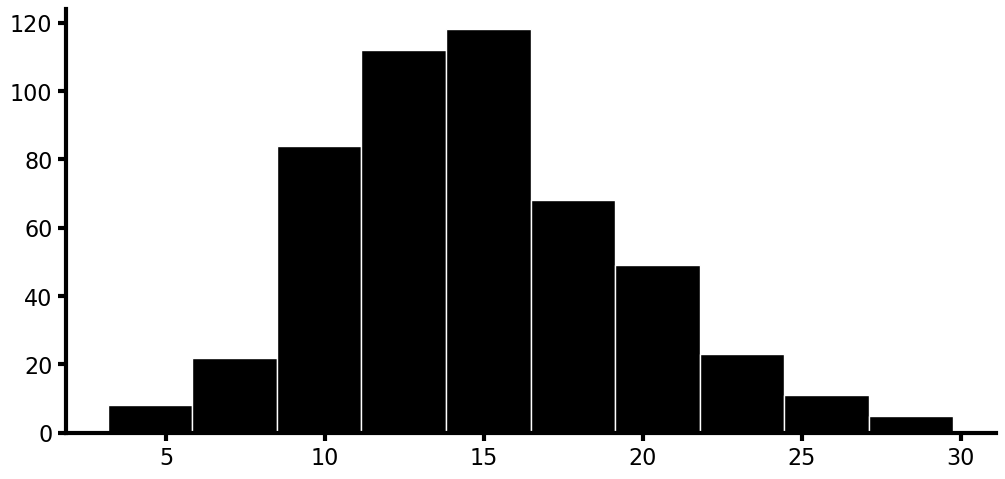

In [10]:
plt.hist(angles_prior)

In [11]:
winds = np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])
windss = [str(w) for w in winds]
THRES = 1e-1

In [12]:
angles = np.zeros((len(dts), len(winds), 500))

w_ = 0
d_ = 0
for dt in dts:
    for w in windss:
        tmp_a1 = dt[w].ds.controls.sel(vari='ALPHA_R1').values
        tmp_a2 = dt[w].ds.controls.sel(vari='ALPHA_R2').values
        tmp_a3 = dt[w].ds.controls.sel(vari='ALPHA_R3').values
        tmp_b1 = dt[w].ds.controls.sel(vari='BETA_R1').values
        tmp_b2 = dt[w].ds.controls.sel(vari='BETA_R2').values
        tmp_b3 = dt[w].ds.controls.sel(vari='BETA_R3').values
        tmp_l = dt[w].ds.controls.sel(vari='L').values
        tmp_g = dt[w].ds.controls.sel(vari='G').values
        tmp_eps = dt[w].ds.controls.sel(vari='EPS').values
        for i in range(Nens):
            angles[d_, w_, i] = get_angle(tmp_a1[i], tmp_a2[i], tmp_a3[i],
                                          tmp_b1[i], tmp_b2[i], tmp_b3[i],
                                          tmp_l[i], tmp_eps[i], tmp_g[i])
        w_ += 1
    d_ += 1
    w_ = 0

/scratch/local/jobs/44717529/ipykernel_2176023/707464132.py:9: RuntimeWarning: overflow encountered in matmul
  num = two_normed @ r_normed
/scratch/local/jobs/44717529/ipykernel_2176023/707464132.py:10: RuntimeWarning: overflow encountered in square
  denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
/scratch/local/jobs/44717529/ipykernel_2176023/707464132.py:11: RuntimeWarning: invalid value encountered in divide
  return np.arccos(num / denom) * 180 / np.pi
/scratch/local/jobs/44717529/ipykernel_2176023/707464132.py:10: RuntimeWarning: overflow encountered in double_scalars
  denom = np.sqrt(np.sum(two_normed**2) * np.sum(r_normed**2))
/scratch/local/jobs/44717529/ipykernel_2176023/707464132.py:4: RuntimeWarning: overflow encountered in double_scalars
  inside = (l + e * g) / phi
/scratch/local/jobs/44717529/ipykernel_2176023/707464132.py:9: RuntimeWarning: invalid value encountered in matmul
  num = two_normed @ r_normed


In [13]:
angles_filtered = np.where(angles > np.percentile(angles_prior, 99.5), np.nan, angles)
angles_filtered.shape

(6, 14, 500)

(array([  7.,  31.,  55., 103.,  85.,  84.,  51.,  32.,  13.,  11.]),
 array([ 8.94930587, 10.78143929, 12.6135727 , 14.44570612, 16.27783954,
        18.10997296, 19.94210638, 21.7742398 , 23.60637322, 25.43850663,
        27.27064005]),
 <BarContainer object of 10 artists>)

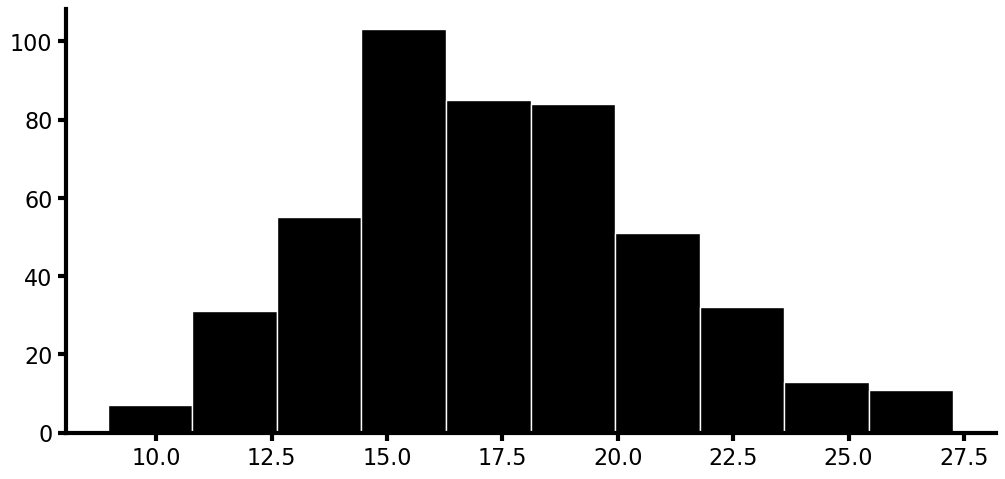

In [14]:
plt.hist(angles_filtered[5, -3])

In [15]:
min(angles_filtered[5, -2])

11.165791653128213

(8.0, 27.0)

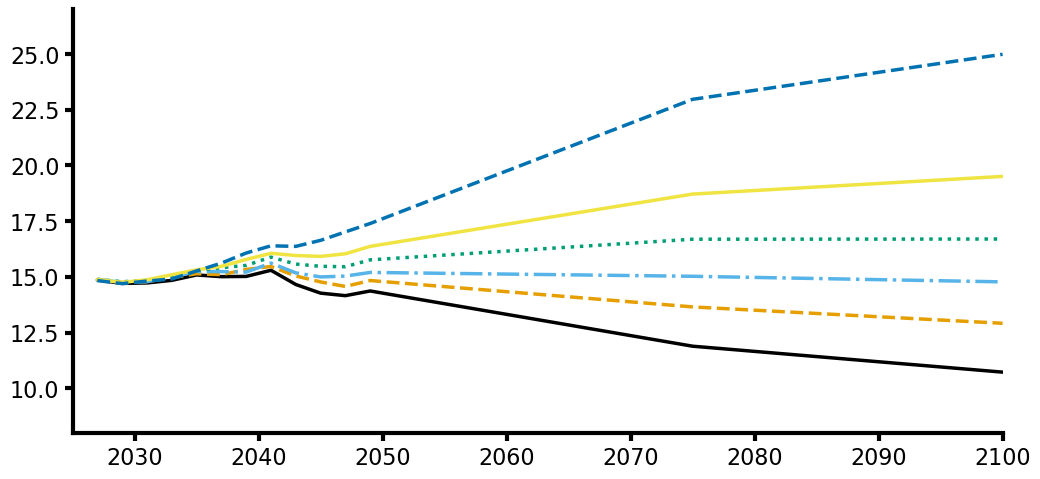

In [16]:
plt.plot(winds, np.nanmean(angles_filtered[0], axis=1), label=angles[0])
plt.plot(winds, np.nanmean(angles_filtered[1], axis=1), label=angles[1])
plt.plot(winds, np.nanmean(angles_filtered[2], axis=1), label=angles[2])
plt.plot(winds, np.nanmean(angles_filtered[3], axis=1), label=angles[2])
plt.plot(winds, np.nanmean(angles_filtered[4], axis=1), label=angles[2])
plt.plot(winds, np.nanmean(angles_filtered[5], axis=1), label=angles[2])

plt.xlim((2025, 2100))
plt.ylim((8, 27))

Figure saved to /project/bbcael/ambauer/learning_sai/analysis/sims/figs/2026-1-27-ens-med-bias-percrange-r3-margobs_ws-ssp245-TMIN2025-AR1-ECS3.0-DEGpDEC0.1-Nwinds14custom-Nens500.svg


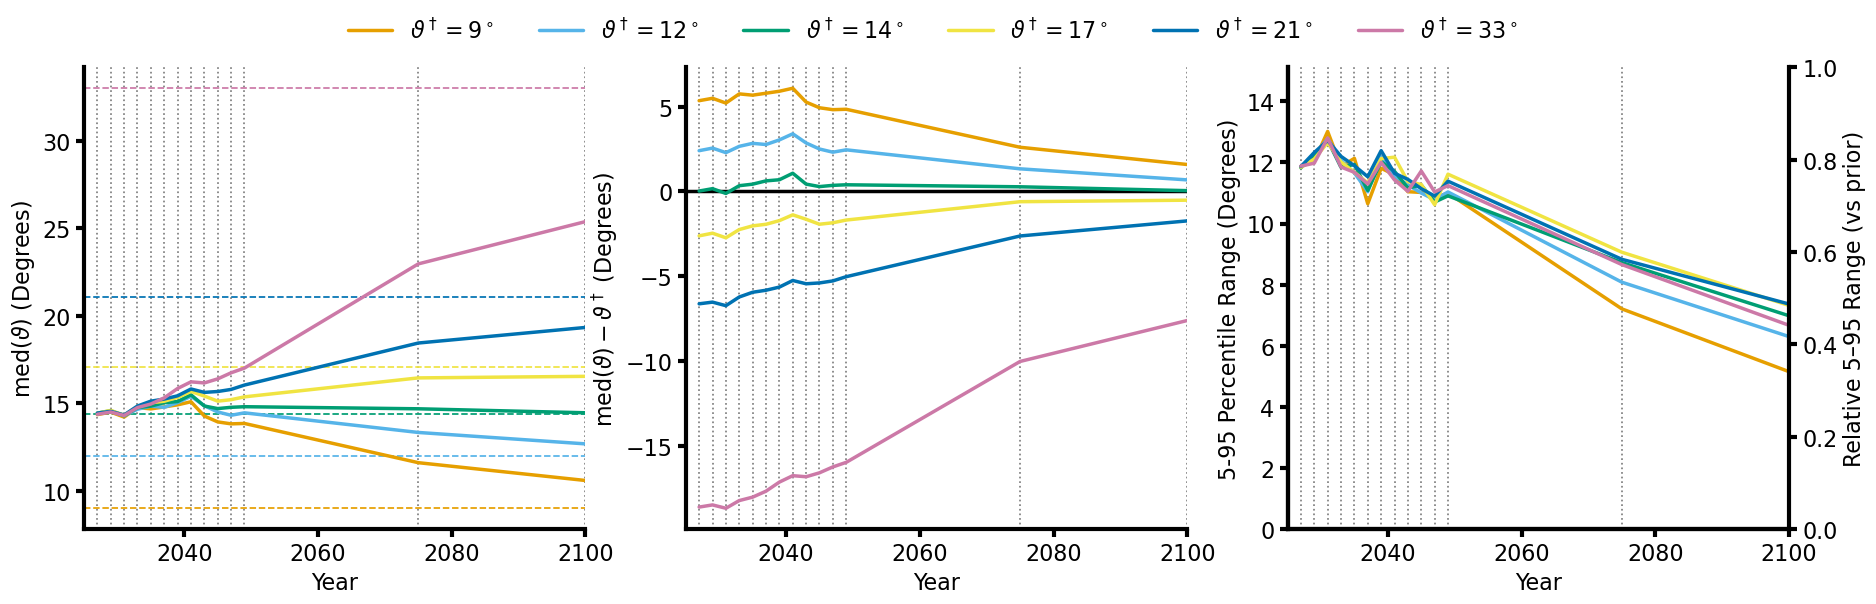

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(22, 6))
color_list = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442',
              '#0072B2', '#CC79A7', '#D55E00']

YMIN, YMAX = 5, 25

for a in ax:
    a.set_xlim((2025, 2100))

for w in winds:
    for a in ax:
        a.axvline(w, linestyle='dotted', color='grey', linewidth=1.25)
        a.set_xlabel("Year")

for i in range(len(angles_file)):
    ax[0].plot(winds, np.nanmedian(angles_filtered[i], axis=1),
               linestyle='solid', color=color_list[i+1],
               label=r'$\vartheta^\dagger=${}$^\circ$'.format(angles_file[i]), zorder=100)

    ax[0].axhline(angles_tr[i], linestyle='dashed', linewidth=1.25, color=color_list[i+1])

    ax[1].plot(winds, np.nanmedian(angles_filtered[i], axis=1) - angles_tr[i], 
           color=color_list[i+1], zorder=100, linestyle='solid')

    ax[2].plot(winds, np.nanpercentile(angles_filtered[i], 95, axis=1) - np.nanpercentile(angles_filtered[i], 5, axis=1), 
           label=r'$\vartheta*=${}$^\circ$'.format(angles_file[0]), zorder=100, color=color_list[i+1], linestyle='solid')

ax[0].set_ylabel(r"med$(\vartheta)$ (Degrees)")
ax[0].legend(bbox_to_anchor=(2.9, 1.15), ncols=len(angles_file))

ax[1].set_ylabel(r"med$(\vartheta) - \vartheta^\dagger$ (Degrees)")
ax[1].axhline(0, color='k', linestyle='solid')

ax[2].set_ylabel(r"5-95 Percentile Range (Degrees)")
ax[2].set_ylim((0, np.percentile(angles_prior, 95) - np.percentile(angles_prior, 5)))

ax2_rel = ax[2].twinx()
ax2_rel.set_ylabel("Relative 5–95 Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)

if SAVE_FIGS:
    filename = "ens-med-bias-percrange-r3-{}-{}-TMIN{}-AR{}-ECS{}-DEGpDEC{}-Nwinds{}-Nens{}.svg".format(prefix, ssp, TMIN, AR, ECS, DEGpDEC, Nwinds, Nens)
    fig.savefig(basefile + filename, dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

plt.show()

In [38]:
import seaborn as sb
import pandas as pd

In [18]:
np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])[-2]

2075

In [26]:
# prepare data for plotting
tr_, yr_ = 2, '2049'  # choose true value index and assimilation year ('obs up to X')
ds = dts[tr_][yr_].ds

angles_sel = angles[tr_, -3]

data = np.zeros((13, Nens))
data[0] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='L').values)
data[1] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='G').values)
data[2] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='EPS').values)
data[3] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C1').values)
data[4] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C2').values)
data[5] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='F1_CO2').values)
data[6] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R1').values)
data[7] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R2').values)
data[8] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R1').values/0.09)
data[9] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R2').values/0.09)
data[10] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, angles_sel)
data[11] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / data[0])
data[12] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / (data[0] + data[1] * data[2]))

In [28]:
df_all = pd.DataFrame(data=data.T,
    columns=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)', r'$\varepsilon$ ($-$)', r'$C_1$', r'$C_2$',
             r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)',
             r'$\beta_{R1}$ (K / W m$^{-2}$)', r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)', 'ECS (K)', 'TCR (K)']
)

In [29]:
df_all

,$\lambda$ (K / W m$^{-2}$),$\gamma$ (K / W m$^{-2}$),$\varepsilon$ ($-$),$C_1$,$C_2$,$f^{(CO_2)}_1$ (W m$^{-2})$,$\alpha_{R1}$ ($-$),$\alpha_{R2}$ ($-$),$\beta_{R1}$ (K / W m$^{-2}$),$\beta_{R2}$ (K / W m$^{-2}$),$\vartheta$ (Degrees),ECS (K),TCR (K)
0,1.099552,0.602144,1.562407,6.074846,145.953288,4.736828,1.914572,1.251645,0.279652,-0.159427,16.385246,4.307961,2.321581
1,1.088971,0.642072,1.792097,8.499670,97.648952,4.913465,1.999790,1.278420,0.084855,-0.240512,12.525957,4.512026,2.193876
2,1.018189,0.637710,1.498996,7.863737,129.991261,4.525562,2.035418,1.320212,0.173608,-0.212597,12.819647,4.444715,2.292452
3,1.013917,0.656226,1.512072,5.677252,122.566559,4.562692,2.045198,1.299711,0.167359,-0.175744,11.590115,4.500066,2.274322
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1.032273,0.719160,1.783489,6.032797,101.062125,4.731520,2.027122,1.287707,0.193993,-0.158413,13.928001,4.583593,2.043953
496,0.561495,0.658567,1.628521,10.468786,108.225369,3.859331,1.976587,1.264827,0.209750,-0.161967,10.494718,6.873312,2.361914
497,1.194472,0.970899,1.439388,3.700279,68.071998,4.934716,2.000289,1.314298,0.160961,-0.247334,17.699172,4.131295,1.903845
498,0.696502,0.996531,1.602832,5.545369,61.296310,4.228056,1.958669,1.285919,0.162479,-0.245375,16.088930,6.070411,1.843276


In [31]:
from scipy import stats
# Assuming your dataframe is called 'df'
theta_col = r'$\vartheta$ (Degrees)'

# Get the independent variable (theta)
theta = df_all[theta_col]

results = {}
r_tot = 0

# Loop through each column
for col in df_all.columns:
    # Skip the theta column itself
    if col == theta_col or col == 'ECS (K)' or col == 'TCR (K)':
        continue
    
    # Get the dependent variable
    y = df_all[col]
    
    # Remove NaN values
    mask = ~(np.isnan(theta) | np.isnan(y))
    theta_clean = theta[mask]
    y_clean = y[mask]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theta[mask], y[mask]
    )

    r_tot += r_value**2
    
    results[col] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err
    }

# Convert to DataFrame and sort by R² (descending)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r_squared', ascending=False)

print(results_df)
print(f"\n\nVariables ranked by variance explained (R²):")
print("="*60)
for i, (var, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {var}")
    print(f"   R² = {row['r_squared']/r_tot:.4f} ({row['r_squared']*100/r_tot:.2f}% variance explained)")
    print(f"   Slope = {row['slope']:.4f}, p-value = {row['p_value']:.4e}\n")

                                  slope   intercept  r_squared       p_value  \
$f^{(CO_2)}_1$ (W m$^{-2})$    0.064613    3.611074   0.147413  3.931744e-18   
$C_2$                         -4.224442  165.412976   0.136055  9.348769e-17   
$\beta_{R1}$ (K / W m$^{-2}$)  0.010845    0.025865   0.111977  6.840775e-14   
$\alpha_{R1}$ ($-$)           -0.020098    2.305455   0.109857  1.213294e-13   
$\gamma$ (K / W m$^{-2}$)      0.019741    0.459856   0.076325  9.072782e-10   
$\alpha_{R2}$ ($-$)           -0.006763    1.406239   0.038888  1.497028e-05   
$\lambda$ (K / W m$^{-2}$)     0.019317    0.729753   0.034766  4.333462e-05   
$\beta_{R2}$ (K / W m$^{-2}$) -0.002185   -0.178477   0.012364  1.532613e-02   
$\varepsilon$ ($-$)            0.004513    1.509193   0.006210  8.621808e-02   
$C_1$                          0.016099    7.618097   0.000321  6.970162e-01   

                                std_err  
$f^{(CO_2)}_1$ (W m$^{-2})$    0.007145  
$C_2$                          0.48

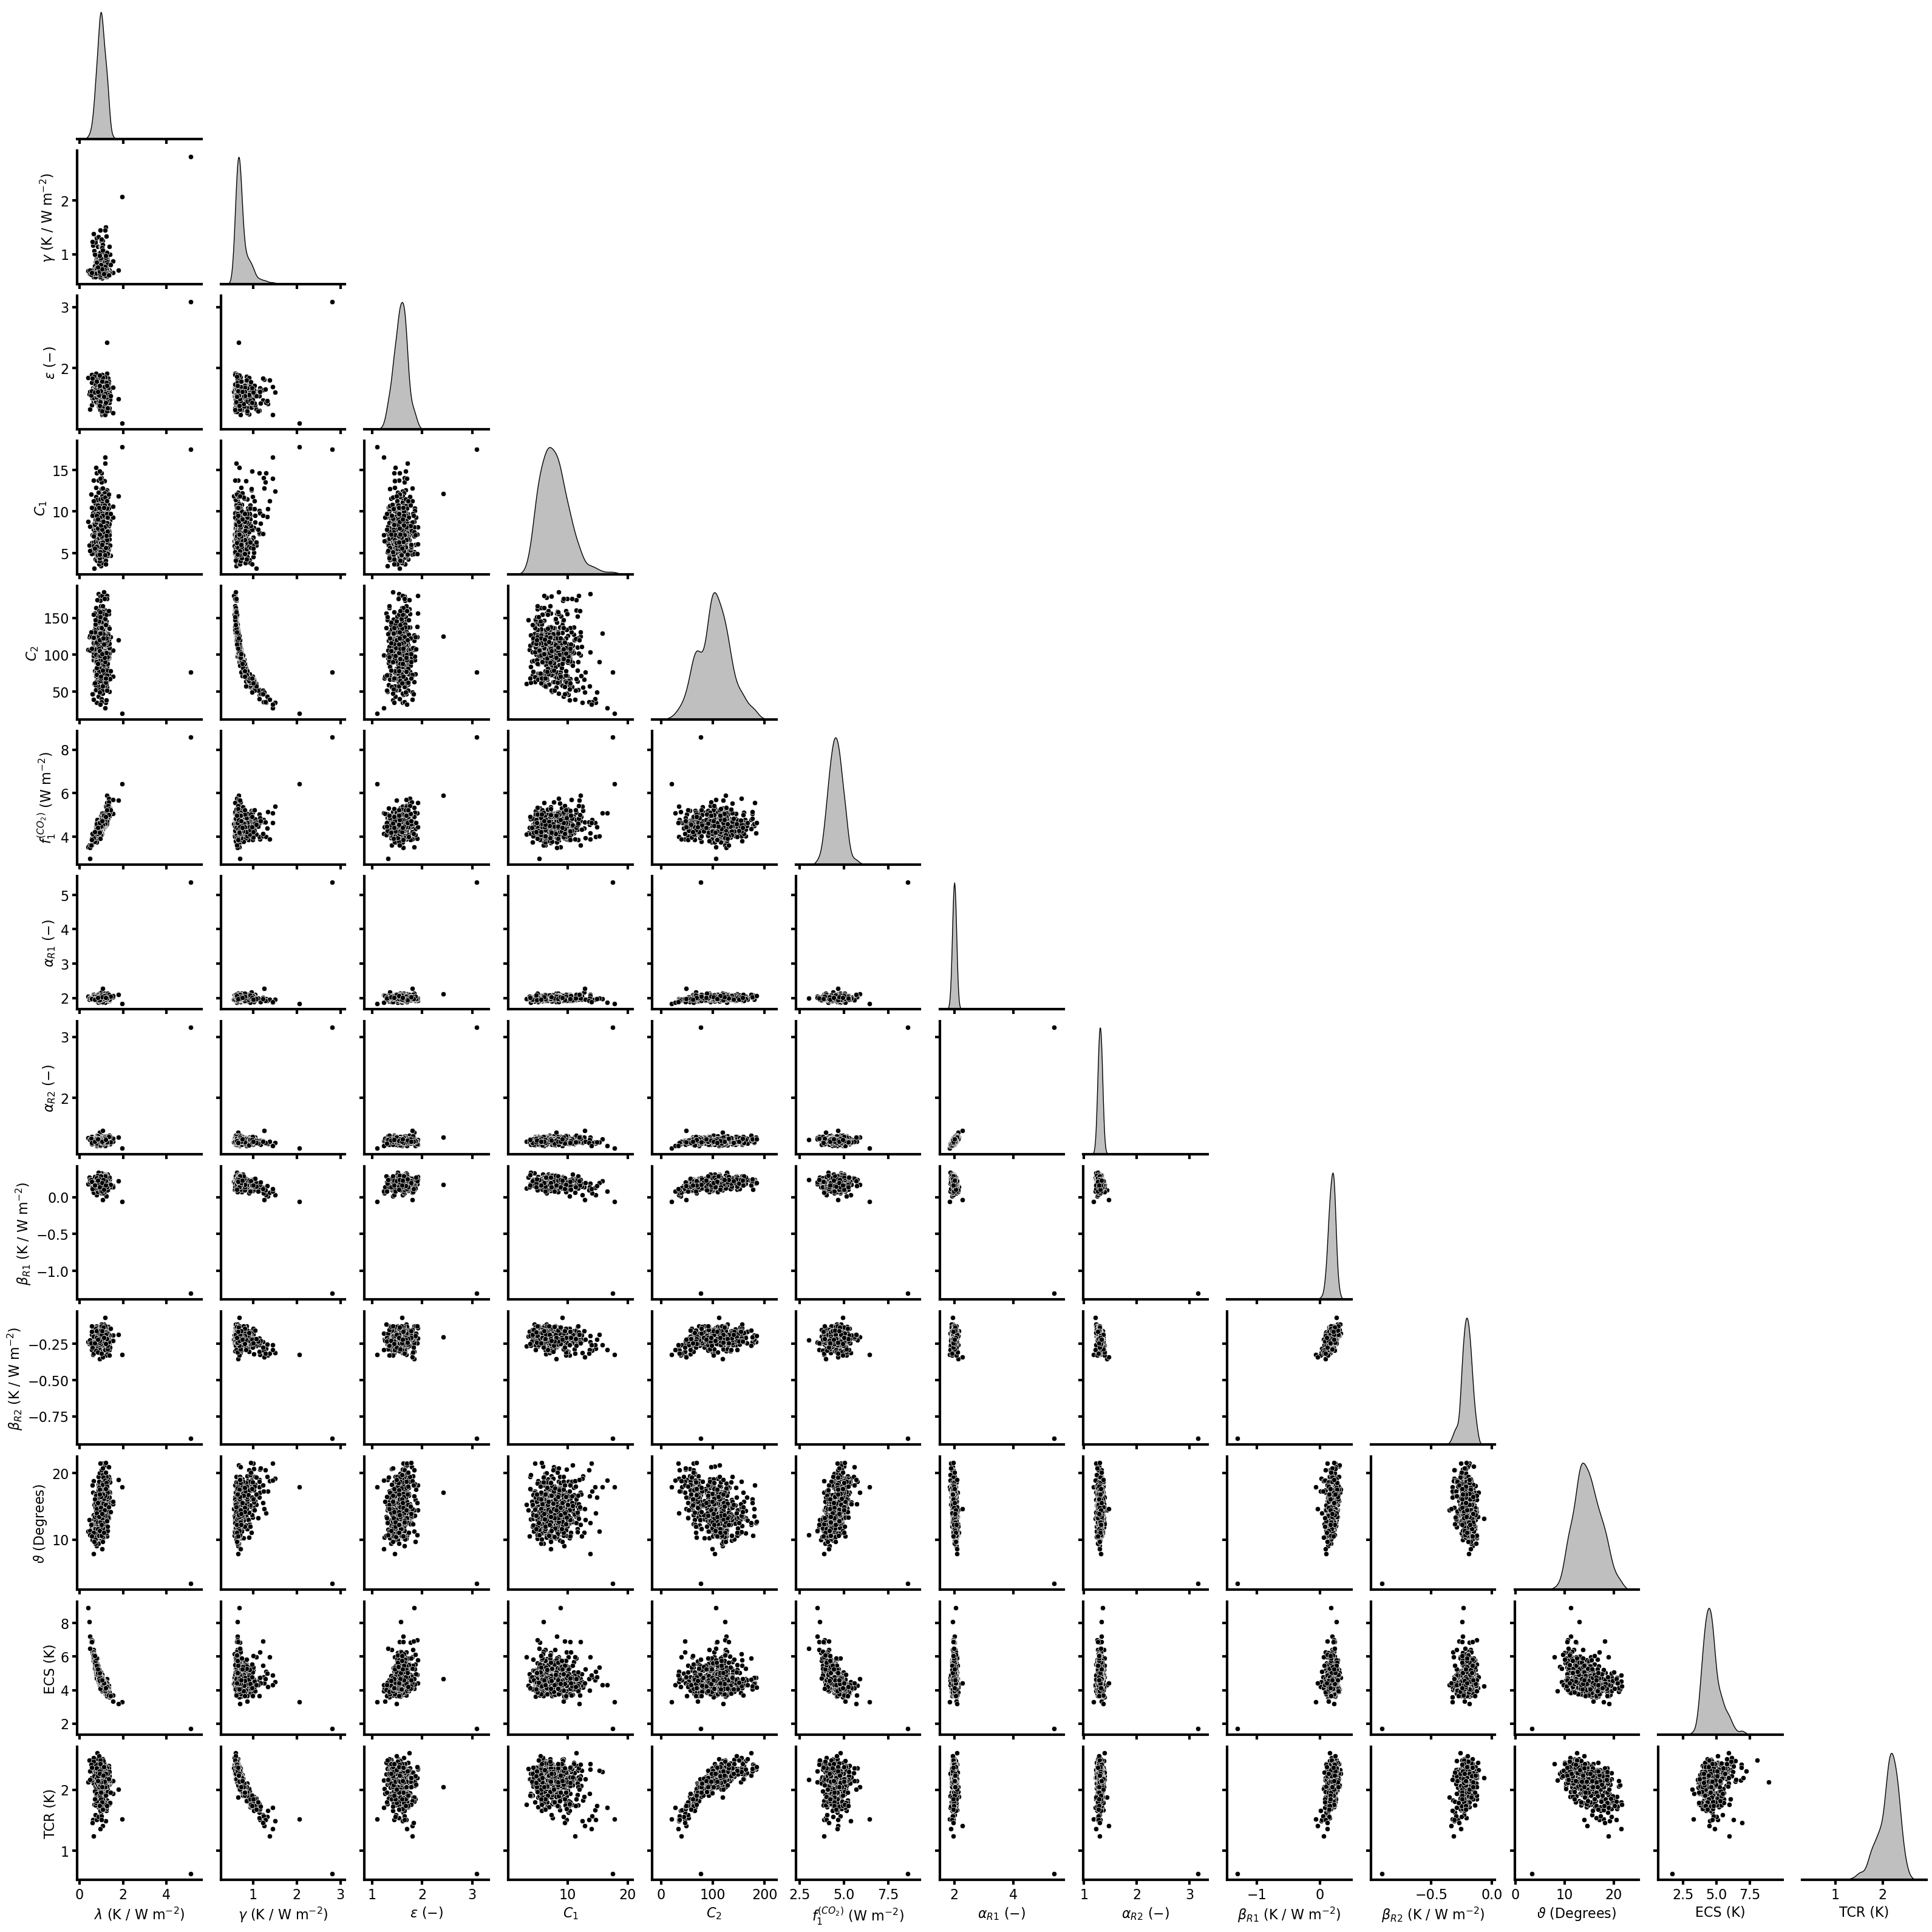

In [33]:
pp = sb.pairplot(df_all,
                diag_kind='kde', corner=True, dropna=True)

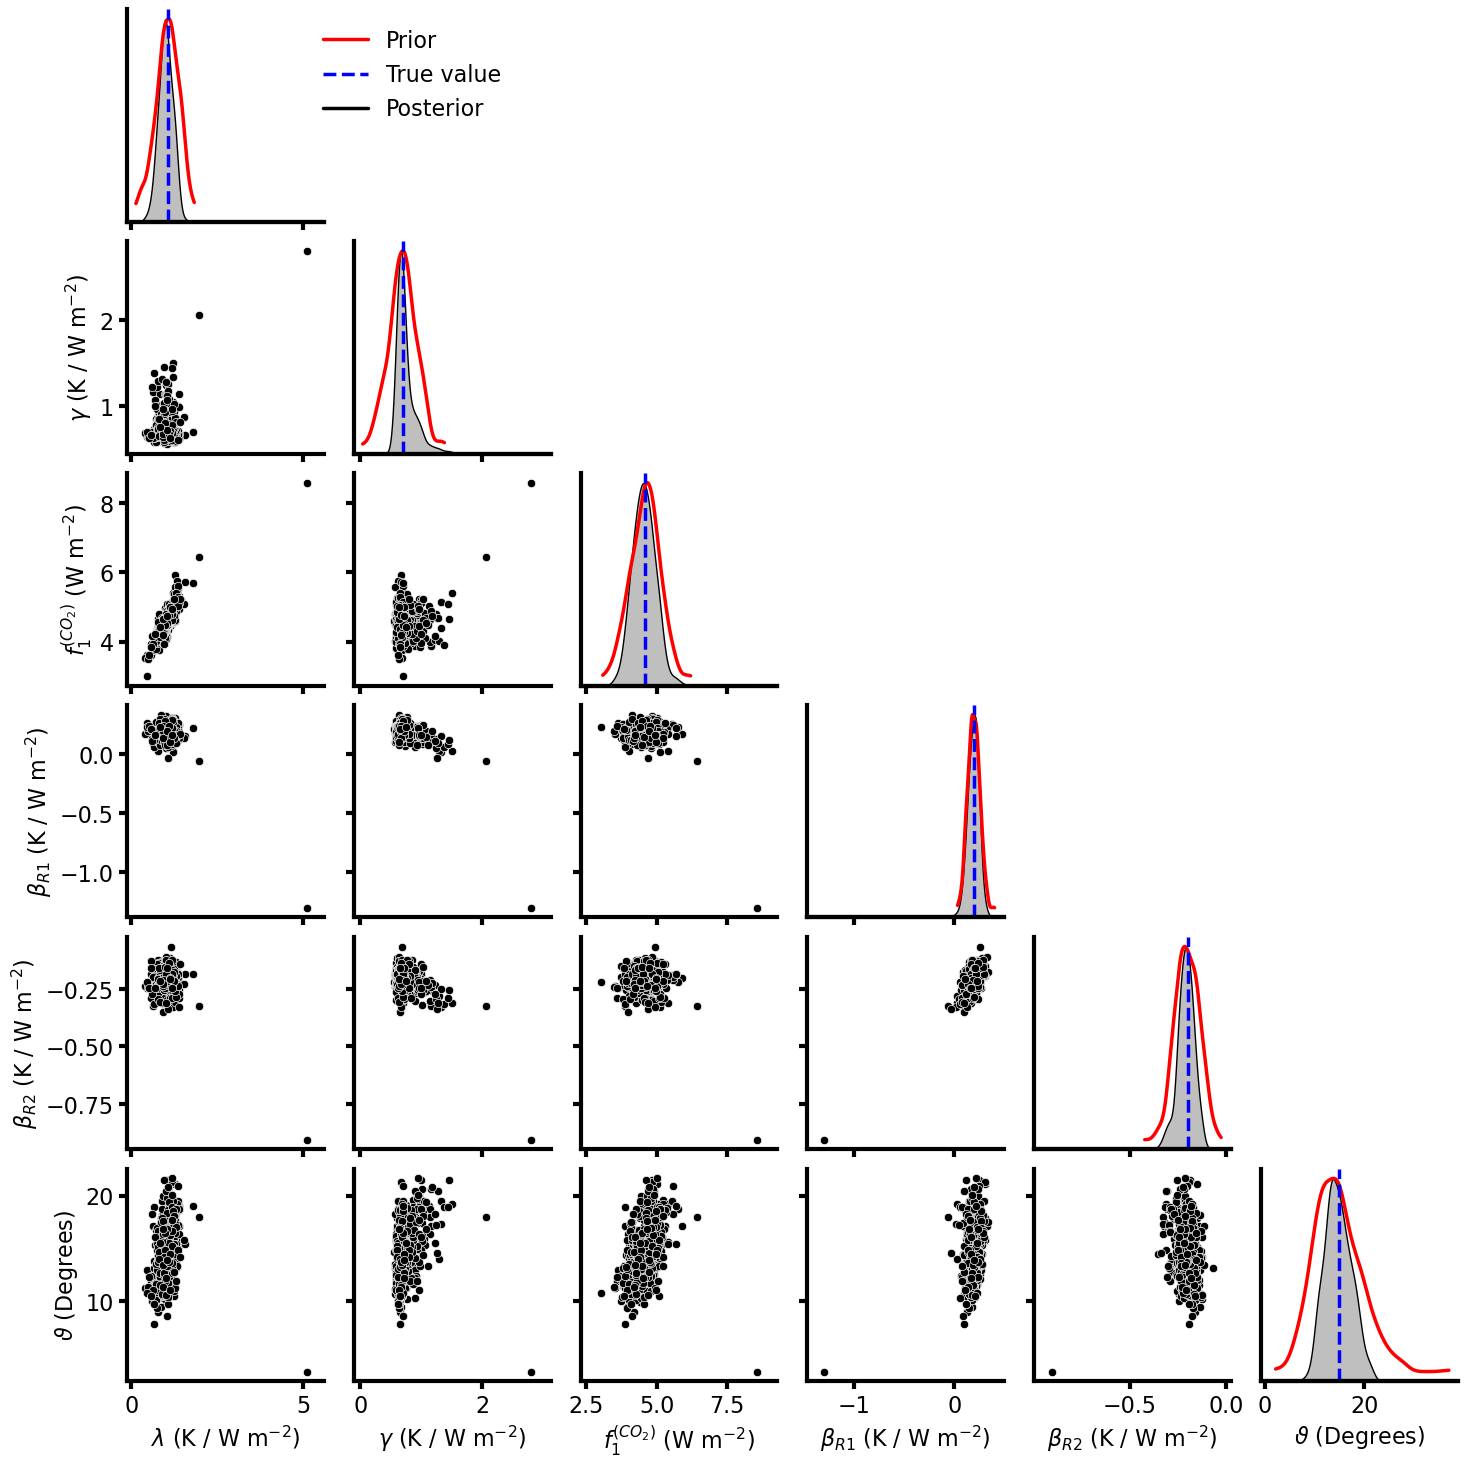

In [32]:

pp = sb.pairplot(df_all, vars=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)',
                               r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\beta_{R1}$ (K / W m$^{-2}$)', 
                               r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)'],
                 diag_kind='kde', corner=True, dropna=True)

prior_f = np.random.normal(4.58, 0.519, size=500)
prior_samples = [prior_l, prior_g, prior_f, prior_b1/0.09, prior_b2/0.09, angles_prior]
var_truth = [L_CEN, G_CEN, 4.58, 0.018/0.09, -0.018/0.09, angles_tr[tr_]]

# add priors on the diagonals
for i, ax in enumerate(pp.diag_axes):
    x = np.linspace(min(prior_samples[i]), max(prior_samples[i]), 200)
    zeros = np.zeros_like(x)
    
    kde = stats.gaussian_kde(prior_samples[i])

    ax2 = ax.twinx()
    ax2.plot(x, kde(x), 'r-', label='Prior', zorder=-1)
    ax2.axvline(var_truth[i], linestyle='dashed', color='b', label="True value")
    ax2.set_xlim((ax.get_xlim()[0], ax.get_xlim()[1]))
    
    #ax2.fill_between(x, zeros, kde(x), alpha=0.3, color='r', zorder=-1)
    
    ax2.set_ylabel('')
    ax2.set_yticks([])

    if i == 0:
        ax2.plot([2.0], [0], 'k-', label="Posterior")
        ax2.legend(bbox_to_anchor=(2.0, 1.0))

if SAVE_FIGS:
    filename = 'corner-regional.svg'
    # pp.savefig(basefile + filename)

In [25]:
results_df

,slope,intercept,r_squared,p_value,std_err
$f^{(CO_2)}_1$ (W m$^{-2})$,0.080893,3.384463,0.223862,1.763979e-28,0.006846
$C_2$,-4.149393,164.372141,0.159174,5.403872e-20,0.433491
$\gamma$ (K / W m$^{-2}$),0.043454,0.129477,0.122682,1.789318e-15,0.005282
$\lambda$ (K / W m$^{-2}$),0.040390,0.436106,0.101585,6.162522e-13,0.005460
$\beta_{R1}$ (K / W m$^{-2}$),0.008345,0.060714,0.078751,3.023641e-10,0.001297
$\alpha_{R1}$ ($-$),-0.008833,2.148468,0.019219,2.190166e-03,0.002868
$\beta_{R2}$ (K / W m$^{-2}$),-0.002180,-0.178500,0.014949,6.963220e-03,0.000804
$C_1$,0.065468,6.931894,0.005891,9.097896e-02,0.038656
$\varepsilon$ ($-$),0.002423,1.538173,0.002047,3.195951e-01,0.002432
$\alpha_{R2}$ ($-$),-0.000626,1.320686,0.000284,7.108360e-01,0.001688


In [60]:
TCRs = np.zeros_like(angles)

w_ = 0
d_ = 0
for dt in dts:
    for w in windss:
        F2x = dt[w].ds.controls.sel(vari='F1_CO2').values
        L = dt[w].ds.controls.sel(vari='L').values
        G = dt[w].ds.controls.sel(vari='G').values
        E = dt[w].ds.controls.sel(vari='EPS').values
        TCRs[d_, w_] = F2x / (L + G * E)
        w_ += 1
    d_ += 1
    w_ = 0

TCRs_filtered = np.where(angles > 40, np.nan, TCRs)

/scratch/local/jobs/43034307/ipykernel_3657920/3501822179.py:11: RuntimeWarning: overflow encountered in multiply
  TCRs[d_, w_] = F2x / (L + G * E)


Text(0.5, 0, '$\\vartheta$ 95-5 Percentile Range')

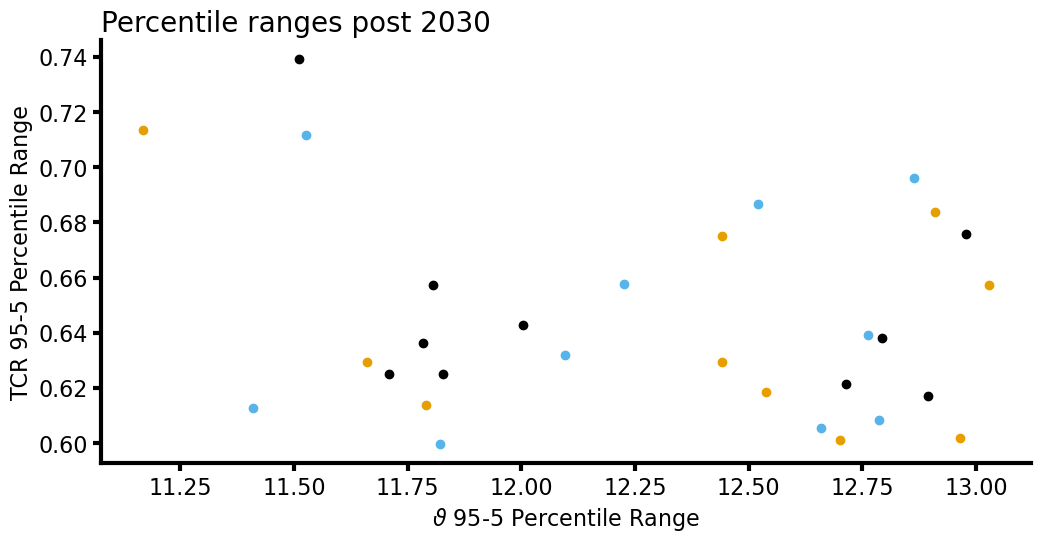

In [61]:
up = 95
lp = 5
lb = 2
ub = -2

plt.scatter(np.nanpercentile(angles_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[0], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[0], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[0], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[1], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[1], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[1], lp, axis=1)[lb:ub])

plt.scatter(np.nanpercentile(angles_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(angles_filtered[2], lp, axis=1)[lb:ub],
            np.nanpercentile(TCRs_filtered[2], up, axis=1)[lb:ub] - np.nanpercentile(TCRs_filtered[2], lp, axis=1)[lb:ub])

plt.title("Percentile ranges post 2030")
plt.ylabel("TCR 95-5 Percentile Range")
plt.xlabel(r"$\vartheta$ 95-5 Percentile Range")

In [119]:
np.nanpercentile(angles_filtered[0], 95, axis=1) - np.nanpercentile(angles_filtered[0], 5, axis=1)


array([16.01771145, 10.01815212,  9.1642755 ,  8.45085075,  8.585393  ,
        8.51978014,  8.66425231,  8.76037209,  7.59673509,  8.21912802,
        7.4736056 ,  7.55186424,  7.15401912,  4.89916573,  4.65988329])

In [95]:
from scipy.stats import describe

describe(angles[0, 2]).mean

14.871032470055844

(array([  1.,   6.,  20.,  61., 115., 132., 101.,  50.,  11.,   3.]),
 array([ 4.94258756,  6.75201492,  8.56144229, 10.37086966, 12.18029703,
        13.9897244 , 15.79915177, 17.60857914, 19.4180065 , 21.22743387,
        23.03686124]),
 <BarContainer object of 10 artists>)

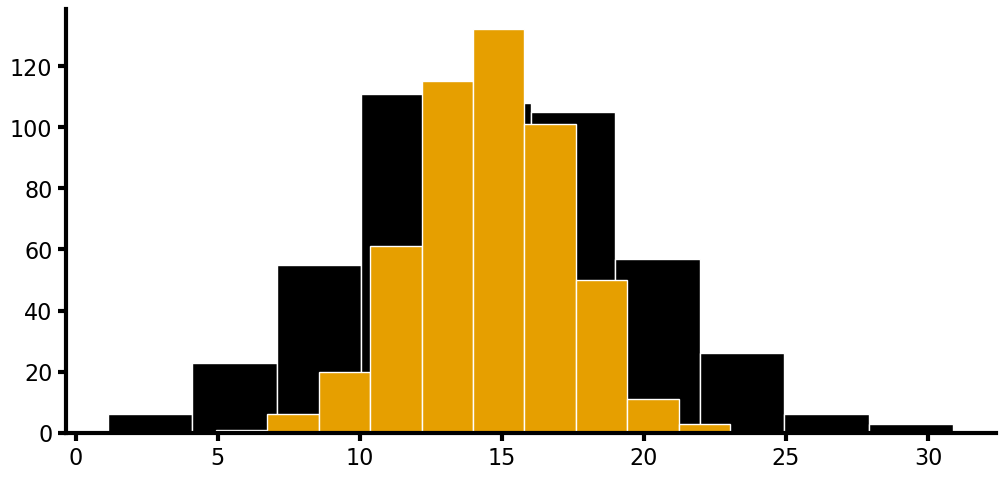

In [96]:
plt.hist(angles_prior)
plt.hist(angles[1, 3])

In [97]:
angles_filtered = np.where(angles > 40, np.nan, angles)
angles_filtered

array([[[12.2808719 , 21.0173075 , 10.69008267, ...,  9.8047894 ,
          9.96688122, 12.50763725],
        [13.92075851, 18.30913514, 16.80098746, ..., 12.65852142,
         18.45609059, 15.08528691],
        [14.68584015, 18.43115577, 15.2822881 , ..., 11.73759066,
         15.5495521 , 13.80605778],
        ...,
        [14.72233635, 13.02911581, 13.51261472, ..., 13.67794241,
         14.51194408, 15.13896651],
        [16.43712839, 13.04752022, 10.83421087, ..., 12.04520787,
         13.24759367,  0.0428931 ],
        [11.1024485 , 13.41730529, 12.01935743, ..., 15.58836531,
         12.17021758, 13.20540263]],

       [[12.2808719 , 21.0173075 , 10.69008267, ...,  9.8047894 ,
          9.96688122, 12.50763725],
        [14.02529536, 18.41729672, 16.83666826, ..., 12.74124134,
         18.58518115, 15.00064089],
        [14.68334974, 18.5620946 , 15.45406808, ..., 13.48817713,
         15.78113123, 13.92521928],
        ...,
        [15.7024941 , 14.13420785, 15.05921122, ..., 1

(array([  1.,   6.,  20.,  61., 115., 132., 101.,  50.,  11.,   3.]),
 array([ 4.94258756,  6.75201492,  8.56144229, 10.37086966, 12.18029703,
        13.9897244 , 15.79915177, 17.60857914, 19.4180065 , 21.22743387,
        23.03686124]),
 <BarContainer object of 10 artists>)

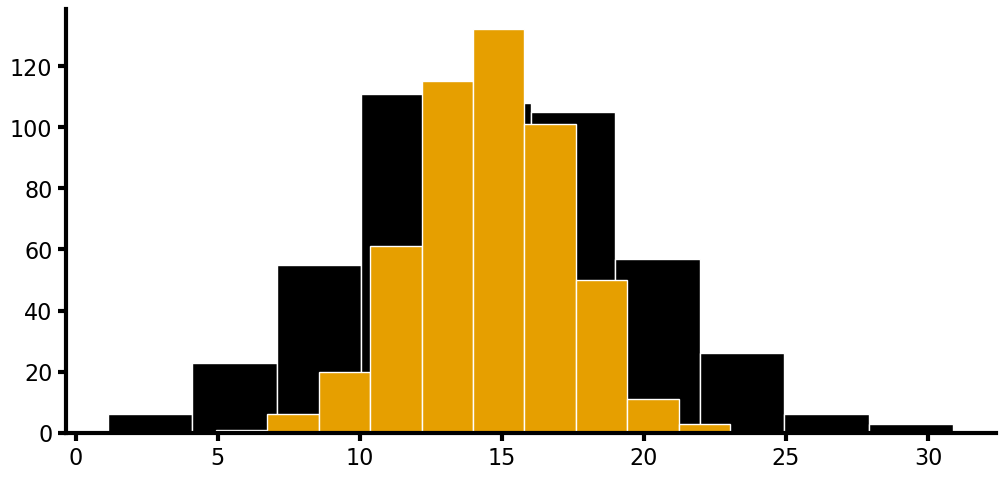

In [98]:
plt.hist(angles_prior)
plt.hist(angles_filtered[1, 3])

In [80]:
x = ['tat', 'tdo', 'q', 'tr1', 'tr2', 'l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2', 'b1', 'b2', 'else']

In [81]:
x


['tat',
 'tdo',
 'q',
 'tr1',
 'tr2',
 'l',
 'g',
 'e',
 'c1',
 'c2',
 'f1',
 'a1',
 'a2',
 'b1',
 'b2',
 'else']

In [82]:
x[5:13]

['l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2']

In [83]:
x[5:12]

['l', 'g', 'e', 'c1', 'c2', 'f1', 'a1']

In [84]:
x[5:14]

['l', 'g', 'e', 'c1', 'c2', 'f1', 'a1', 'a2', 'b1']

# OLD STUFF THAT IS DEPRECIATED AND / OR WRONG

In [6]:
# THIS IS OLD AND DEPRECIATED
def get_angle_OLD(a1, b1, a2, b2, a1cent, a2cent, lam, f_eff):
    # convert betas into xis
    prefactor1 = lam / (f_eff * a1cent)
    prefactor2 = lam / (f_eff * a2cent)
    xi1 = b1 * prefactor1
    xi2 = b2 * prefactor2

    # coefficient on SAI contribution to temperature rise
    comp1 = a1cent * (xi1 - 1)
    comp2 = a2cent * (xi2 - 1)

    # angle components
    ang_num = a1 * b1 + a2 * b2
    ang_denom = np.sqrt(
        (a1**2 + a2**2) * (b1**2 + b2**2)
    )
    return np.arccos(ang_num / ang_denom) * 180 / np.pi